# YBa$_2$Cu$_3$O$_6$ EFG point charge calculation

In [1]:
from pymatgen.core import Structure
import numpy as np
import pyEFGPointCharge
%matplotlib notebook
from isotopeDict import isotope_data_dict


## Load cif, prepare calc

In [2]:
# load a cif file and create a pymatgen.core.structure.Structure object with the info from said file.

cif_file_name = 'Cava_1990_EntryWithCollCode66903.cif'

structure = Structure.from_file(cif_file_name)
print(structure)


Full Formula (Ba2 Y1 Cu3 O6)
Reduced Formula: Ba2Y(CuO2)3
abc   :   3.854400   3.854400  11.817500
angles:  90.000000  90.000000  90.000000
Sites (12)
  #  SP         a    b       c
---  -------  ---  ---  ------
  0  Ba2+     0.5  0.5  0.8056
  1  Ba2+     0.5  0.5  0.1944
  2  Y3+      0.5  0.5  0.5
  3  Cu1.67+  0    0    0
  4  Cu1.67+  0    0    0.6398
  5  Cu1.67+  0    0    0.3602
  6  O2-      0    0    0.8489
  7  O2-      0    0    0.1511
  8  O2-      0    0.5  0.6209
  9  O2-      0.5  0    0.6209
 10  O2-      0    0.5  0.3791
 11  O2-      0.5  0    0.3791


## Calculation

In [7]:
sphere_radius = 150


### Cu(1)

In [8]:
# instantiate the classes and define the relevant attributes therein.

# input_parameters is a class within the imported pyEFGPointCharge module
input_pars_Cu1 = pyEFGPointCharge.input_parameters()

##########################
# general input parameters
##########################
# path to cif file
input_pars_Cu1.cif_file_name = cif_file_name

# create a supercell if one is required to define the magnetic structure
# the supercell_dimensions parameter should be a list of form [Na, Nb, Nc],
# where Na, Nb, and Nc are integers that represent the number of unit cells
# in the crystallographic a, b, and c directions, respectivly, contained in
# the supercell. For example, [1, 1, 2] will create a supercell that is 
# 1 x 1 x 2 unit cells in size. Note: creating a supercell modifies the
# lattice as well, therefore one must specify the magnetic_site_indices,
# probe indices, etc. in the supercell. see the following for details
# dipole_hyperfine_lattice_sum/ipynb_examples/LiCuVO4/
# LiCuVO4_dipole_hyperfine_calc_2021-08-30.ipynb
input_pars_Cu1.supercell_dimensions = [1, 1, 1]

# choose the radius around which we will include spins in angstroms with 
# respect to the probe position (float)
input_pars_Cu1.sphere_radius = sphere_radius

# define the probe site number (nuclear spin site) (int)
input_pars_Cu1.probe_site_index = 3

# for performing large calculations, we want to attempt to keep enough 
# memory. To do this we'll trash some arrays that we don't need
# running on 32bit python would cause memory allocation errors, so to 
# make the program more portable, we can allow for that memory to be 
# freed by the garbage collector by setting (no longer needed arrays 
# to None)
input_pars_Cu1.delete_plotting_arrays = False

# probe nucleus identifying dictionary key (from isotope_data_dict) (string)
# e.g. '11B'
input_pars_Cu1.probe_nucleus = "63Cu_arneil" #(Q = -0.211)

# or if you want to set a custom nuclear quadrupole moment, do that here and
# the default for the probe nucleus will be overridden
input_pars_Cu1.manual_nuclear_quad_moment = None

# in that case one also needs to define the nuclear spin I
input_pars_Cu1.manual_nuclear_spin = None

# define the charge sites by index in the cif file (list of ints)
# Note: that site indices in pymatgen start at zero.
# Further Note: if creating a supercell, one must include all magetic 
# site indices in the supercell. therefore the user must first know the 
# site indices.
input_pars_Cu1.charge_site_indices = [i for i in range(12)]

# charges should be set to be a numpy array of shape = (len(charge_site_indices),), 
# the order of the charges should be the same as the charge_site_indices. units 
# are in multiples of the elementary charge e.
# Example:
# define antiferromagnetic order on the  magnetic sites with indices 0 and 1,
# so above charge_site_indices = [0, 1], and there is a charge of -2 on site 0
# and a +1 charge on site 1, then charges = np.array([-2.0, 1.0])
input_pars_Cu1.first_cell_charges = [ 2,  2,  3,
                                      1,  2,  2,
                                     -2, -2, -2,
                                     -2, -2, -2]

# Sternheimer factor (need to implement this, but for now just leave the variable as a placeholder)
input_pars_Cu1.gamma_sternheimer = -5.5

results_Cu1 = pyEFGPointCharge.results()
# a class for returning results of the calculation
# all results are in cartesian coordinates!!!
#class results:
    ## the structure object created from the cif file
    #structure = None
    ## a matrix representing the the lattice unit cell as row vectors in 
    ## cartesian coordinates (angstroms)
    #lattice = None
    ## Charge positions (angstroms)
    #charge_positions = None
    ## charges, in units of the elementary charge e
    #charges = None
    ## raw EFG tensor, ie not diagonalized (V m^-2)
    #V_ab_raw = None
    ## raw eigenvalues of the EFG tensor, ordered such that 
    ## |V_xx| <= |V_yy| <= |V_zz|; where x, y, and z no longer correspond to the 
    ## cartesian axes, but indicate the directions of the principal axes of the
    ## EFG tensor (V m^-2)
    #V_aa = None
    ## eigenvectors of the EFG tensor  (principal axes directions)
    ## (normalized, cartesian coordinates, a matrix of column vectors, 
    ## order is the same as the V_aa)
    #principal_axes = None
    ## eta = (V_xx - V_yy)/V_zz
    #eta = None
    ## nu_z = 3eQV_zz/(2I(2I-1)h)
    #nu_z_MHz = None
    ## nu_Q_MHz = nu_z_MHz(1 - eta**2/3)**0.5
    #nu_Q_MHz = None

###############################################################################

# run the calc
pyEFGPointCharge.calc_EFG_point_charge(input_pars_Cu1, results_Cu1)

# if we kept the vectors for plotting, then say how many spins we included in the calculation
if not input_pars_Cu1.delete_plotting_arrays:
    N_charges = results_Cu1.charge_positions.shape[0]
    print('calculated the EFG tensor via lattice sum for',
          '{:e}'.format(N_charges),
          'charges')
    

calculated the EFG tensor via lattice sum for 9.661780e+05 charges


In [9]:
# print the results (all in Cartesian coordinates)
print('structure =')
print(results_Cu1.structure)
print('')
print('lattice (angstroms) =')
print(results_Cu1.lattice)
print('')
print('probe_position (angstroms) =')
print(results_Cu1.probe_position)
print('')
print('V_ab_raw (V m^-2) =')
print(results_Cu1.V_ab_raw)
print('')
print('V_aa (V m^-2) =')
print(results_Cu1.V_aa)
print('')
print('principal_axes (unitless) =')
print(results_Cu1.principal_axes)
print('')
print('eta (unitless) =')
print(results_Cu1.eta)
print('')
print('nu_z (MHz) =')
print(results_Cu1.nu_z_MHz)
print('')
print('nu_Q (MHz) =')
print(results_Cu1.nu_Q_MHz)
print('')


#print('charge_positions (angstroms) =')
#print(results_Cu1.charge_positions)
#print('')
#print('charges (units of e) =')
#print(results_Cu1.charges)
#print('')


structure =
Full Formula (Ba2 Y1 Cu3 O6)
Reduced Formula: Ba2Y(CuO2)3
abc   :   3.854400   3.854400  11.817500
angles:  90.000000  90.000000  90.000000
Sites (12)
  #  SP         a    b       c    charge
---  -------  ---  ---  ------  --------
  0  Ba2+     0.5  0.5  0.8056         2
  1  Ba2+     0.5  0.5  0.1944         2
  2  Y3+      0.5  0.5  0.5            3
  3  Cu1.67+  0    0    0              1
  4  Cu1.67+  0    0    0.6398         2
  5  Cu1.67+  0    0    0.3602         2
  6  O2-      0    0    0.8489        -2
  7  O2-      0    0    0.1511        -2
  8  O2-      0    0.5  0.6209        -2
  9  O2-      0.5  0    0.6209        -2
 10  O2-      0    0.5  0.3791        -2
 11  O2-      0.5  0    0.3791        -2

lattice (angstroms) =
[[ 3.85440000e+00  0.00000000e+00  0.00000000e+00]
 [-2.36013931e-16  3.85440000e+00  0.00000000e+00]
 [ 7.23613177e-16  7.23613177e-16  1.18175000e+01]]

probe_position (angstroms) =
[0. 0. 0.]

V_ab_raw (V m^-2) =
[[ 6.29396547e+21  1.248

<IPython.core.display.Javascript object>


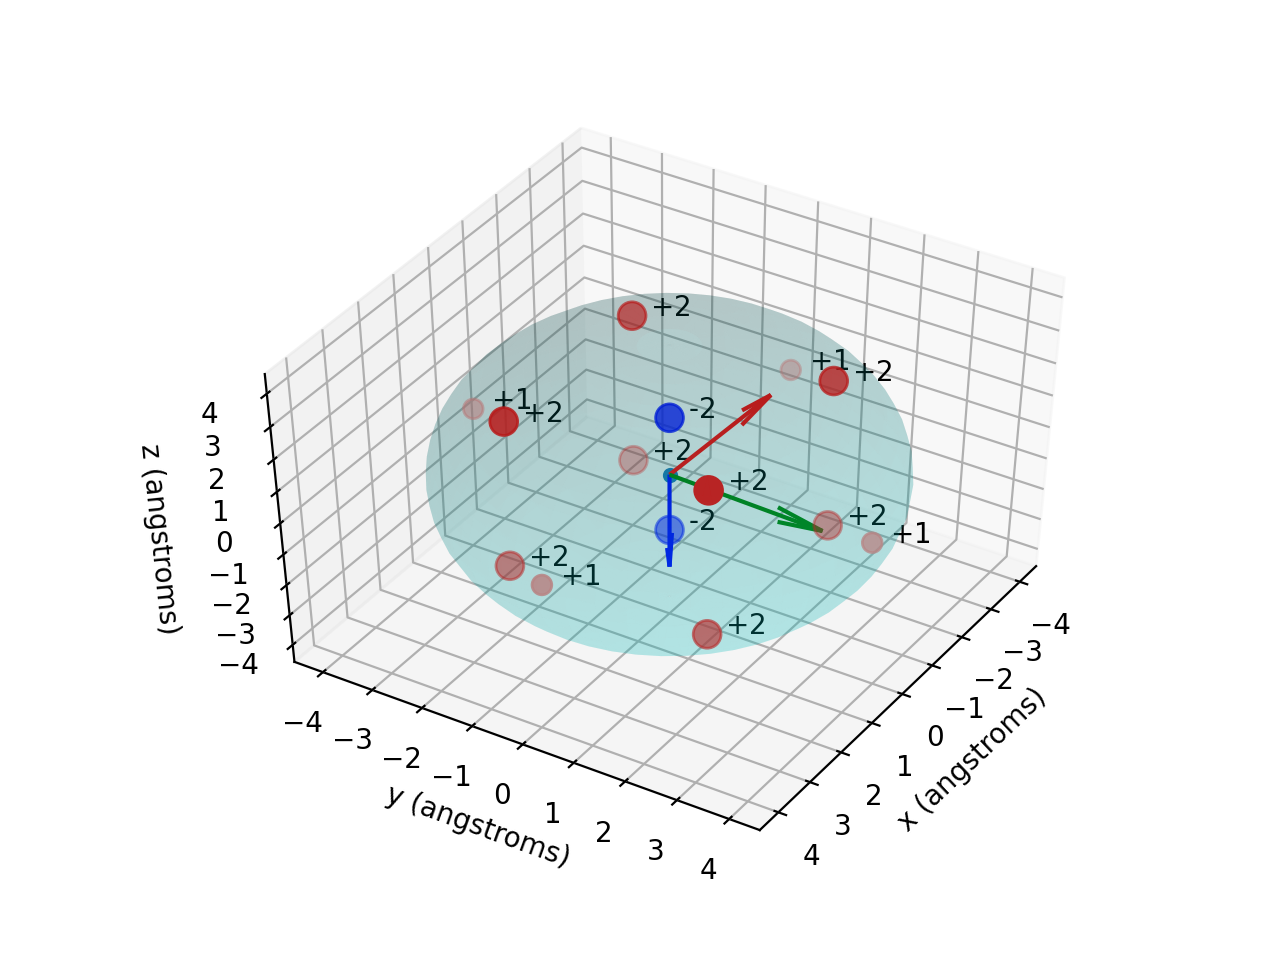

In [6]:
# display a visualization (note, should only do this for less than approx
# 50 atoms or it is not helpful

#%matplotlib notebook

# define the point-inclusion limits as a tuple
minmax=10
x_min_rel = -minmax
x_max_rel = minmax
y_min_rel = -minmax
y_max_rel = minmax
z_min_rel = -minmax
z_max_rel = minmax
pos_limits = (x_min_rel, x_max_rel, y_min_rel, y_max_rel, z_min_rel, z_max_rel)

# set the axes limits as a tuple
axes_min = -minmax
axes_max = minmax
ax_range = (axes_min, axes_max, axes_min, axes_max, axes_min, axes_max)

# uncommment to execute the visualization, also make sure delete_plotting_arrays = False
pyEFGPointCharge.visualization(input_parameters=input_pars_Cu1,
                               results=results_Cu1,
                               relative_position_limits=pos_limits,
                               axes_range=None,
                               elev=0.,
                               azim=0.,
                               plot_sphere=True,
                               plot_lattice_vectors=False)

## to do

verify code against other calculations
